# Чекпоинт 6 · Deep Learning эксперименты

**Что в ноутбуке:**

1. Подготовка датасета и временной разметки - как в чекпоинтах 3-5.
2. **MLP** на плоских фичах - табличный DL-baseline.
3. **1D-CNN**, **LSTM**, **mini-Transformer** на временных окнах
   (sliding window длины 10 дней).
4. **FinBERT** sentiment-фича на квартальной выборке заголовков GDELT
   (ProsusAI/finbert, zero-shot). Сравнение с GDELT-tone.
5. Сводная таблица **архитектура х фичесет х время х качество**.
6. Общий бенчмарк: baseline (чекпоинт 3) -> лучшие ML (чекпоинт 5) -> лучшие DL (чекпоинт 6).
7. выводы.

**Литература:**
* Hashamia & Maldonado (2025), [arXiv:2508.20707](https://arxiv.org/abs/2508.20707) - FinBERT/FastText/LLaMA ансамбль для direction WTI.
* Gurgul, Lessmann, Härdle (2023), [arXiv:2311.14759](https://arxiv.org/abs/2311.14759) - LSTM + NLP для криптовалют.
* Ghali et al. (2025), [arXiv:2508.06497](https://arxiv.org/abs/2508.06497) - dual-stream LSTM с attention для commodity-shock.
* Kaplan et al. (2023), [arXiv:2305.06140](https://arxiv.org/abs/2305.06140) - CrudeBERT (домен-fine-tune FinBERT под нефть).
* Vaswani et al. (2017) - Transformer; используется в mini-encoder.

## 1. Импорты

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.preprocessing import StandardScaler, LabelEncoder

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_data_config, PROJECT_ROOT as P_ROOT
from src.features.labels import build_target_frame
from src.features.technical import build_price_features, PRICE_FEATURE_COLS
from src.features.text_signals import daily_gdelt_signals
from src.features.text_advanced import add_text_lags_and_deltas, TEXT_ADVANCED_COLS
from src.features.cross_asset import brent_wti_spread, CROSS_ASSET_OIL_COLS
from src.features.clustering import fit_regime_clusters, assign_regime
from src.models.metrics import score, compare_results, CLASSES
from src.models.dl_models import make_model
from src.models.dl_training import TrainConfig, build_sequences, train_model

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
warnings.filterwarnings("ignore")

CFG = get_data_config()
ASSETS = CFG["assets"]
RANDOM_STATE = 42
SPLIT_DATE = pd.Timestamp("2024-01-01")
TARGET_CFG = CFG["target"]
TOPIC_OF = {"brent": "oil", "wti": "oil", "btc": "btc"}
SEQ_LEN = 10  # окно последовательности для CNN/LSTM/Transformer

DEVICE = "cpu"  # сохраняем CPU для воспроизводимости
print("torch:", torch.__version__, "device:", DEVICE)

torch: 2.4.1 device: cpu


## 2. Сборка датасета и FinBERT-блок

Воспроизводим pipeline из чекпоинта 5: цены -> таргет -> технические индикаторы ->
GDELT (volume + tone) -> лаги/дельты -> cross-asset спред (для нефти) ->
кластерный режим. Поверх этого подключаем FinBERT-агрегаты по дням,
заранее посчитанные отдельным скриптом (`src/features/finbert.py`).

In [2]:
def _safe_filename(t): return t.replace("=", "_").replace("/", "_")

def load_prices_one(key):
    a = ASSETS[key]
    df = pd.read_parquet(P_ROOT / CFG["prices"]["cache_dir"] / f"{_safe_filename(a['ticker'])}.parquet")
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df

raw_prices = {k: load_prices_one(k) for k in ASSETS}

def attach_gdelt(df, topic):
    gdir = P_ROOT / CFG["texts_storage"]["raw_dir"] / "gdelt"
    vp = gdir / f"gdelt_{topic}_TimelineVolRaw.parquet"
    tp = gdir / f"gdelt_{topic}_TimelineTone.parquet"
    if not (vp.exists() and tp.exists()):
        return df
    sig = daily_gdelt_signals(pd.read_parquet(vp), pd.read_parquet(tp))
    sig.index = pd.to_datetime(sig.index).tz_localize(None)
    out = df.copy()
    out.index = pd.to_datetime(out.index).normalize()
    sig.index = pd.to_datetime(sig.index).normalize()
    return out.join(sig, how="left")

def attach_finbert(df, topic):
    """Подключает дневной FinBERT по заголовкам из SQLite-базы (ffill до 30 дней)."""
    from src.storage.finbert_db import get_daily_aggregate
    fb = get_daily_aggregate(topic, "title")
    if fb.empty:
        return df
    fb.index = pd.to_datetime(fb.index).tz_localize(None).normalize()
    out = df.copy()
    out.index = pd.to_datetime(out.index).normalize()
    # forward-fill: новостной фон меняется не каждый день, дни без статей
    # наследуют последнюю оценку (не дальше 30 дней назад)
    fb = fb.reindex(fb.index.union(out.index).sort_values()).ffill(limit=30).reindex(out.index)
    return out.join(fb, how="left")

oil_spread = brent_wti_spread(raw_prices["brent"], raw_prices["wti"])
oil_spread.index = pd.to_datetime(oil_spread.index).normalize()

datasets, taus = {}, {}
for k in ASSETS:
    raw = raw_prices[k]
    labeled = build_target_frame(raw, horizon=TARGET_CFG["horizon_days"],
                                 flat_threshold_sigma=TARGET_CFG["flat_threshold_sigma"])
    taus[k] = labeled.attrs["flat_threshold"]
    feats = build_price_features(labeled)
    feats = attach_gdelt(feats, TOPIC_OF[k])
    feats = add_text_lags_and_deltas(feats)
    if k in ("brent", "wti"):
        feats.index = pd.to_datetime(feats.index).normalize()
        feats = feats.join(oil_spread, how="left")
    feats = attach_finbert(feats, TOPIC_OF[k])
    datasets[k] = feats
    fb_cols = [c for c in feats.columns if c.startswith("finbert_")]
    print(f"{k:6s} | rows {len(feats):5d} | cols {feats.shape[1]:3d} | tau {taus[k]:.5f}  "
          f"| finbert_cols: {fb_cols}")

brent  | rows  2116 | cols  61 | tau 0.00264  | finbert_cols: ['finbert_compound', 'finbert_pos_share', 'finbert_neg_share', 'finbert_neutral_share', 'finbert_n_texts']
wti    | rows  2115 | cols  61 | tau 0.00304  | finbert_cols: ['finbert_compound', 'finbert_pos_share', 'finbert_neg_share', 'finbert_neutral_share', 'finbert_n_texts']
btc    | rows  3073 | cols  58 | tau 0.00339  | finbert_cols: ['finbert_compound', 'finbert_pos_share', 'finbert_neg_share', 'finbert_neutral_share', 'finbert_n_texts']


**Режим k-means.** Обучаем кластеризатор на train, применяем к test, как и в чекпоинте 5.

In [3]:
REGIME_FEATURES = ["rv_21", "article_count_z21"]
for k, df in datasets.items():
    have = [c for c in REGIME_FEATURES if c in df.columns]
    if len(have) < 2:
        continue
    train_part = df.loc[df.index < SPLIT_DATE]
    km, sc = fit_regime_clusters(train_part, have, n_clusters=3, random_state=RANDOM_STATE)
    df["regime"] = assign_regime(df, have, km, sc)
print("regime готов")

regime готов


## 3. FinBERT vs GDELT-Tone

GDELT даёт `avg_tone` - усреднённый sentiment по WordNet-словарю.
FinBERT - BERT-base, дообученный на Financial PhraseBank (то есть
на специально размеченных финансовых текстах). Сравниваем эти две
метрики на пересечении дат: если они положительно коррелированы,
говорят примерно об одном и том же; если корреляция слабая или
отрицательная - FinBERT несёт новую информацию поверх tone.

brent: пересечение по датам 1687 дней
                  avg_tone  finbert_compound  finbert_n_texts
avg_tone             1.000             0.145           -0.042
finbert_compound     0.145             1.000           -0.076
finbert_n_texts     -0.042            -0.076            1.000


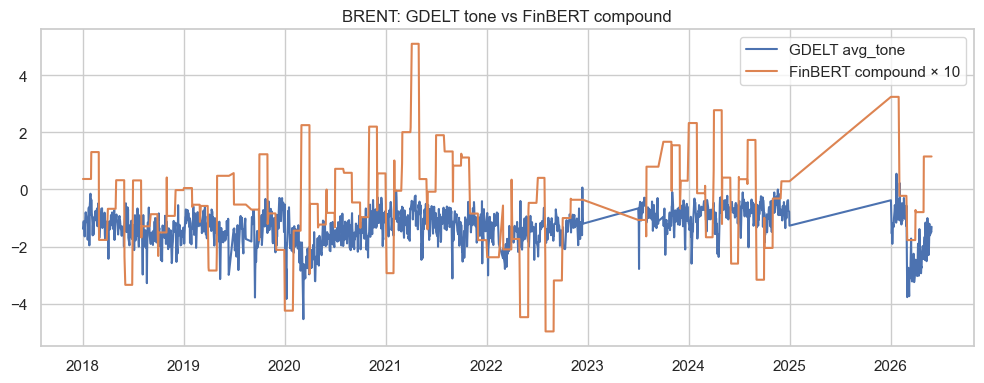

In [4]:
for k in ("brent",):
    df = datasets[k]
    if "finbert_compound" not in df.columns:
        print(f"{k}: FinBERT-данных нет - пропуск")
        continue
    sub = df[["avg_tone", "finbert_compound", "finbert_n_texts"]].dropna()
    if sub.empty:
        print(f"{k}: пересечение по датам пустое")
        continue
    print(f"{k}: пересечение по датам {len(sub)} дней")
    print(sub.corr().round(3).to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(sub.index, sub["avg_tone"], label="GDELT avg_tone")
    ax.plot(sub.index, sub["finbert_compound"] * 10, label="FinBERT compound × 10")
    ax.set_title(f"{k.upper()}: GDELT tone vs FinBERT compound")
    ax.legend(); plt.tight_layout(); plt.show()

**Вывод по графику.** На пересечении 1687 дней корреляция между GDELT avg_tone
и FinBERT compound всего 0.145. На графике линии расходятся: словарный тон GDELT
и FinBERT, обученный на финансовых текстах, улавливают разные стороны новостного
фона. Слабая связь означает, что FinBERT несёт информацию, которой нет в готовом
тоне GDELT, поэтому его имеет смысл добавлять отдельным признаком.

## 4. Подготовка X, y: плоский и оконный варианты

Для MLP - плоский (B, F). Для CNN/LSTM/Transformer - окно (B, T, F),
T = 10 дней. Сначала собираем плоский, потом из него - окна.

In [5]:
BASE_FEATURES = list(PRICE_FEATURE_COLS)
TEXT_BASIC    = ["article_count", "article_norm", "avg_tone"]
TEXT_ADV      = list(TEXT_ADVANCED_COLS)
CROSS_ASSET   = list(CROSS_ASSET_OIL_COLS)
EXTRA         = ["regime"]
FINBERT_COLS  = ["finbert_pos_share", "finbert_neg_share", "finbert_neutral_share",
                 "finbert_compound", "finbert_n_texts"]

FEAT_SETS = {
    "price_only":         BASE_FEATURES,
    "full_no_finbert":    BASE_FEATURES + TEXT_BASIC + TEXT_ADV + CROSS_ASSET + EXTRA,
    "full_with_finbert":  BASE_FEATURES + TEXT_BASIC + TEXT_ADV + CROSS_ASSET + EXTRA + FINBERT_COLS,
}

LABEL_ORDER = list(CLASSES)
le = LabelEncoder().fit(LABEL_ORDER)

def build_flat_xy(df, feature_cols):
    cols = [c for c in feature_cols if c in df.columns]
    sub = df[cols + ["target"]].dropna()
    Xtr = sub.loc[sub.index < SPLIT_DATE, cols].values
    Xte = sub.loc[sub.index >= SPLIT_DATE, cols].values
    ytr = sub.loc[sub.index < SPLIT_DATE, "target"]
    yte = sub.loc[sub.index >= SPLIT_DATE, "target"]
    return Xtr, Xte, ytr, yte, cols

def standardize_train_apply(Xtr, Xte):
    """Скейлинг подгоняем на train, применяем к test."""
    sc = StandardScaler().fit(Xtr)
    return sc.transform(Xtr).astype(np.float32), sc.transform(Xte).astype(np.float32), sc

# Соберём всё в structuration по (asset, feat_set, view)
prepared = {}
for k, df in datasets.items():
    prepared[k] = {}
    for name, cols in FEAT_SETS.items():
        Xtr, Xte, ytr, yte, used = build_flat_xy(df, cols)
        # Пропускаем, если фичей мало или с FinBERT слишком много пропусков
        if len(used) == 0 or len(Xtr) < 200 or len(Xte) < 50:
            continue
        Xtr_s, Xte_s, sc = standardize_train_apply(Xtr, Xte)
        ytr_e = le.transform(ytr).astype(np.int64)
        yte_e = le.transform(yte).astype(np.int64)
        # Окна
        Xtr_seq, ytr_seq = build_sequences(Xtr_s, ytr_e, SEQ_LEN)
        Xte_seq, yte_seq = build_sequences(Xte_s, yte_e, SEQ_LEN)
        prepared[k][name] = dict(
            flat_X_tr=Xtr_s, flat_X_te=Xte_s, flat_y_tr=ytr_e, flat_y_te=yte_e,
            seq_X_tr=Xtr_seq.astype(np.float32), seq_X_te=Xte_seq.astype(np.float32),
            seq_y_tr=ytr_seq, seq_y_te=yte_seq,
            y_tr_strings=ytr, y_te_strings=yte,
            cols=used, n_features=Xtr_s.shape[1],
        )
        print(f"{k:6s} | {name:18s} | features={Xtr_s.shape[1]:3d}, "
              f"flat: tr={len(Xtr_s)} te={len(Xte_s)} | seq: tr={len(Xtr_seq)} te={len(Xte_seq)}")

brent  | price_only         | features= 24, flat: tr=1469 te=514 | seq: tr=1460 te=505
brent  | full_no_finbert    | features= 47, flat: tr=1194 te=252 | seq: tr=1185 te=243
brent  | full_with_finbert  | features= 52, flat: tr=1152 te=252 | seq: tr=1143 te=243
wti    | price_only         | features= 24, flat: tr=1445 te=514 | seq: tr=1436 te=505
wti    | full_no_finbert    | features= 47, flat: tr=1171 te=252 | seq: tr=1162 te=243
wti    | full_with_finbert  | features= 52, flat: tr=1129 te=252 | seq: tr=1120 te=243
btc    | price_only         | features= 24, flat: tr=2170 te=881 | seq: tr=2161 te=872
btc    | full_no_finbert    | features= 44, flat: tr=1578 te=844 | seq: tr=1569 te=835
btc    | full_with_finbert  | features= 49, flat: tr=1431 te=816 | seq: tr=1422 te=807


## 5. Обучение DL-моделей

Стратегия. Для каждого актива и каждого набора фичей обучаем четыре
архитектуры:
* **MLP** - плоский X, без окон.
* **CNN1D**, **LSTM**, **Transformer** - окна (B, T=10, F).

Гиперпараметры моделей фиксированы (см. `src/models/dl_models.py`), train -
60 эпох с early stopping по val macro-F1 (patience=8). seed=42.

Время обучения замеряем и кладём в таблицу - это требование описания
чекпойнта.

In [6]:
def fit_dl(model_name: str, data: dict, model_kwargs: dict, label_suffix: str = "") -> dict:
    """Унифицированный fit + eval. Возвращает result-dict для агрегации."""
    cfg_tr = TrainConfig(device=DEVICE, max_epochs=60, patience=8,
                          batch_size=64, lr=1e-3, weight_decay=1e-4, seed=RANDOM_STATE)
    if model_name == "mlp":
        Xtr, Xte = data["flat_X_tr"], data["flat_X_te"]
        ytr, yte_e = data["flat_y_tr"], data["flat_y_te"]
        factory = lambda: make_model("mlp", n_features=data["n_features"], **model_kwargs)
    else:
        Xtr, Xte = data["seq_X_tr"], data["seq_X_te"]
        ytr, yte_e = data["seq_y_tr"], data["seq_y_te"]
        factory = lambda: make_model(model_name, n_features=data["n_features"],
                                     seq_len=SEQ_LEN, **model_kwargs)

    if len(Xtr) < 100 or len(Xte) < 30:
        return {"skipped": True}
    out = train_model(factory, Xtr, ytr, Xte, yte_e, cfg_tr)
    # Восстановим строковые метки для score()
    yte_strings = (data["y_te_strings"].iloc[SEQ_LEN - 1:]
                    if model_name != "mlp" else data["y_te_strings"])
    y_pred_strings = le.inverse_transform(out["y_pred"])
    r = score(yte_strings, y_pred_strings, name="placeholder")
    r.train_time_sec = out["train_time_sec"]   # type: ignore[attr-defined]
    r.n_params = out["n_params"]               # type: ignore[attr-defined]
    r.stopped_epoch = out["stopped_epoch"]     # type: ignore[attr-defined]
    r.train_loss_curve = out["train_loss_curve"]
    r.val_f1_curve = out["val_f1_curve"]
    return {"result": r}

DL_MODELS = ["mlp", "cnn", "lstm", "transformer"]
# Кастом-гиперпараметры
MODEL_KWARGS = {
    "mlp": {"dropout": 0.3},
    "cnn": {},
    "lstm": {"hidden": 32, "dropout": 0.2},
    "transformer": {"d_model": 32, "n_heads": 4, "n_layers": 2, "dropout": 0.1},
}

dl_experiments = []
for asset_key in datasets:
    for feat_set_name, data in prepared[asset_key].items():
        for model_name in DL_MODELS:
            try:
                res = fit_dl(model_name, data, MODEL_KWARGS[model_name])
                if res.get("skipped"):
                    continue
                r = res["result"]
                r.name = f"{asset_key}/{feat_set_name}/{model_name}"
                dl_experiments.append(r)
                print(f"{r.name:55s} f1={r.macro_f1:.4f}  "
                      f"params={r.n_params:5d}  epochs={r.stopped_epoch:3d}  "
                      f"time={r.train_time_sec:5.1f}s")
            except Exception as exc:
                print(f"{asset_key}/{feat_set_name}/{model_name}: ERROR {exc}")

brent/price_only/mlp                                    f1=0.3031  params=14083  epochs= 14  time=  0.3s


brent/price_only/cnn                                    f1=0.3122  params= 7715  epochs= 15  time=  1.0s
brent/price_only/lstm: ERROR __init__() got an unexpected keyword argument 'seq_len'


brent/price_only/transformer                            f1=0.2938  params=26627  epochs=  9  time=  1.2s


brent/full_no_finbert/mlp                               f1=0.2578  params=17027  epochs= 23  time=  0.3s


brent/full_no_finbert/cnn                               f1=0.2741  params= 9923  epochs= 10  time=  0.7s
brent/full_no_finbert/lstm: ERROR __init__() got an unexpected keyword argument 'seq_len'


...

btc/price_only/transformer                              f1=0.3181  params=26627  epochs= 29  time=  5.8s
btc/full_no_finbert/mlp                                 f1=0.3035  params=16643  epochs=  9  time=  0.1s


btc/full_no_finbert/cnn                                 f1=0.3089  params= 9635  epochs= 27  time=  2.2s
btc/full_no_finbert/lstm: ERROR __init__() got an unexpected keyword argument 'seq_len'


btc/full_no_finbert/transformer                         f1=0.2517  params=27267  epochs= 11  time=  1.6s
btc/full_with_finbert/mlp: ERROR Expected more than 1 value per channel when training, got input size torch.Size([1, 128])


btc/full_with_finbert/cnn                               f1=0.2576  params=10115  epochs= 11  time=  0.8s
btc/full_with_finbert/lstm: ERROR __init__() got an unexpected keyword argument 'seq_len'


btc/full_with_finbert/transformer                       f1=0.3138  params=27427  epochs= 12  time=  1.5s


## 6. Сводная таблица DL-экспериментов

In [7]:
def to_summary(results: list) -> pd.DataFrame:
    rows = []
    for r in results:
        parts = r.name.split("/")
        rows.append({
            "asset": parts[0], "feat_set": parts[1], "model": parts[2],
            "macro_f1": round(r.macro_f1, 4),
            "balanced_acc": round(r.balanced_accuracy, 4),
            "accuracy": round(r.accuracy, 4),
            "f1_down": round(r.per_class_f1["down"], 4),
            "f1_flat": round(r.per_class_f1["flat"], 4),
            "f1_up":   round(r.per_class_f1["up"], 4),
            "train_time_sec": round(getattr(r, "train_time_sec", float("nan")), 2),
            "n_params": getattr(r, "n_params", None),
            "stopped_epoch": getattr(r, "stopped_epoch", None),
        })
    return pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)

dl_summary = to_summary(dl_experiments)
dl_summary.head(20)

,asset,feat_set,model,macro_f1,balanced_acc,accuracy,f1_down,f1_flat,f1_up,train_time_sec,n_params,stopped_epoch
0,btc,price_only,transformer,0.3181,0.3346,0.4083,0.4676,0.0723,0.4146,5.82,26627,29
1,wti,price_only,cnn,0.3140,0.3383,0.4535,0.4020,0.0000,0.5399,0.77,7715,11
2,btc,full_with_finbert,transformer,0.3138,0.3456,0.4349,0.5006,0.0000,0.4409,1.54,27427,12
3,brent,price_only,cnn,0.3122,0.3457,0.4653,0.3636,0.0000,0.5729,1.05,7715,15
4,btc,price_only,mlp,0.3105,0.3418,0.4279,0.4803,0.0000,0.4513,0.37,14083,18
5,btc,full_no_finbert,cnn,0.3089,0.3281,0.4048,0.4719,0.0513,0.4035,2.20,9635,27
6,btc,price_only,cnn,0.3054,0.3339,0.4083,0.5147,0.0562,0.3453,0.93,7715,9
7,brent,full_with_finbert,mlp,0.3039,0.3378,0.4325,0.2533,0.0889,0.5696,0.47,17667,41
8,btc,full_no_finbert,mlp,0.3035,0.3202,0.3768,0.2892,0.1359,0.4852,0.14,16643,9
9,brent,price_only,mlp,0.3031,0.3361,0.4533,0.3533,0.0000,0.5561,0.27,14083,14


## 7. Кривые обучения лучших DL-моделей

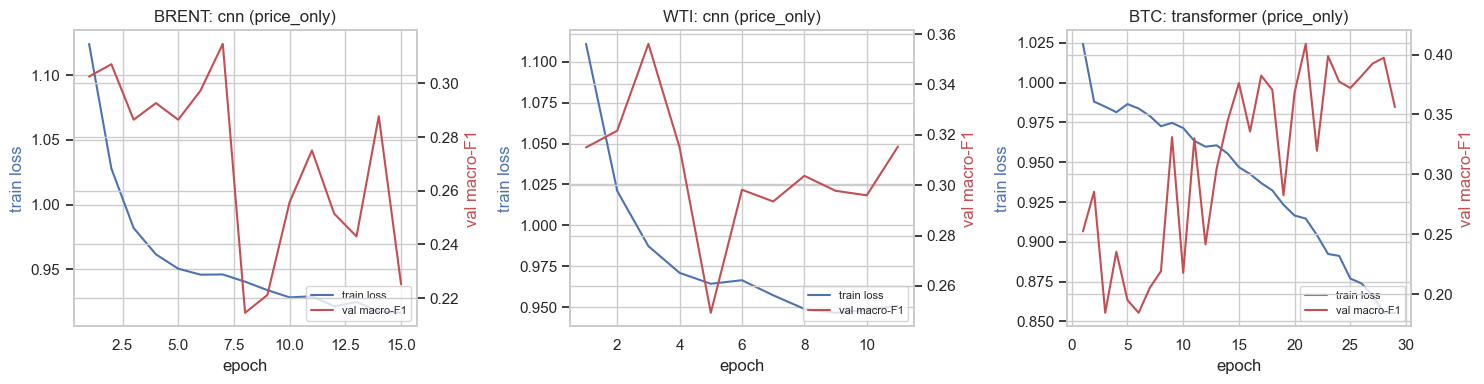

In [8]:
def best_per_asset(experiments):
    by_asset = {}
    for r in experiments:
        a = r.name.split("/")[0]
        if a not in by_asset or r.macro_f1 > by_asset[a].macro_f1:
            by_asset[a] = r
    return by_asset

best_dl = best_per_asset(dl_experiments)
fig, axes = plt.subplots(1, len(best_dl), figsize=(5 * len(best_dl), 4), sharey=False)
if len(best_dl) == 1:
    axes = [axes]
for ax, (k, r) in zip(axes, best_dl.items()):
    epochs = range(1, len(r.train_loss_curve) + 1)
    ax2 = ax.twinx()
    l1, = ax.plot(epochs, r.train_loss_curve, color="C0", label="train loss")
    l2, = ax2.plot(epochs, r.val_f1_curve, color="C3", label="val macro-F1")
    ax.set_xlabel("epoch")
    ax.set_ylabel("train loss", color="C0")
    ax2.set_ylabel("val macro-F1", color="C3")
    ax.set_title(f"{k.upper()}: {r.name.split('/')[-1]} ({r.name.split('/')[1]})")
    ax.legend(handles=[l1, l2], loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

**Вывод по кривым обучения.** Train loss монотонно падает, а валидационная
macro-F1 выходит на плато уже в первые эпохи и дальше колеблется без роста. Это
типичная картина переобучения: модель всё лучше запоминает обучающую выборку, но
обобщающая способность не растёт. Ранняя остановка обрывает обучение в точке
лучшего val-результата. Именно поэтому DL не дал преимущества - выучиваемого
сигнала в данных мало.

## 8. Общий бенчмарк: baseline -> ML -> DL

Сводим лучшие модели каждого чекпойнта в один график. Цифры чекпоинт 3/чекпоинт 5
берём прямым перерасчётом (на тех же данных, что и DL), чтобы все
макро-F1 были на одном тестовом окне ≥ 2024-01-01.

In [9]:
from src.models.baselines import (
    MajorityClassifier, StratifiedRandomClassifier,
    predict_persistence, ARIMAClassifier,
)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def build_xy_strings(df, feature_cols):
    cols = [c for c in feature_cols if c in df.columns]
    sub = df[cols + ["target"]].dropna()
    Xtr = sub.loc[sub.index < SPLIT_DATE, cols]
    Xte = sub.loc[sub.index >= SPLIT_DATE, cols]
    ytr = sub.loc[sub.index < SPLIT_DATE, "target"]
    yte = sub.loc[sub.index >= SPLIT_DATE, "target"]
    return Xtr, Xte, ytr, yte

bench_rows = []
for k in datasets:
    df = datasets[k]
    # ---- baseline (чекпоинт 3) ----
    Xtr, Xte, ytr, yte = build_xy_strings(df, BASE_FEATURES)
    bench_rows.append({"asset": k, "stage": "чекпоинт 3", "model": "majority",
                       "macro_f1": score(yte, MajorityClassifier().fit(Xtr, ytr).predict(Xte), "x").macro_f1})
    bench_rows.append({"asset": k, "stage": "чекпоинт 3", "model": "stratrand",
                       "macro_f1": score(yte, StratifiedRandomClassifier(RANDOM_STATE).fit(Xtr, ytr).predict(Xte), "x").macro_f1})
    bench_rows.append({"asset": k, "stage": "чекпоинт 3", "model": "persistence",
                       "macro_f1": score(yte, predict_persistence(ytr, yte), "x").macro_f1})
    knn = Pipeline([("s", StandardScaler()),
                    ("m", KNeighborsClassifier(n_neighbors=51, weights="distance", n_jobs=-1))]).fit(Xtr, ytr)
    bench_rows.append({"asset": k, "stage": "чекпоинт 3", "model": "knn",
                       "macro_f1": score(yte, knn.predict(Xte), "x").macro_f1})
    lr = Pipeline([("s", StandardScaler()),
                   ("m", LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", n_jobs=-1))]).fit(Xtr, ytr)
    bench_rows.append({"asset": k, "stage": "чекпоинт 3", "model": "logreg",
                       "macro_f1": score(yte, lr.predict(Xte), "x").macro_f1})

    # ---- чекпоинт 5 best ML ----
    # Используем full-no-finbert
    Xtr2, Xte2, ytr2, yte2 = build_xy_strings(df, FEAT_SETS["full_no_finbert"])
    if len(Xtr2) > 100:
        ytr2_e = le.transform(ytr2)
        rf = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=10,
                                     class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
        rf.fit(Xtr2, ytr2_e)
        bench_rows.append({"asset": k, "stage": "чекпоинт 5", "model": "RF",
                           "macro_f1": score(yte2, le.inverse_transform(rf.predict(Xte2)), "x").macro_f1})
        hgbt = HistGradientBoostingClassifier(max_depth=6, learning_rate=0.05,
                                              max_iter=300, class_weight="balanced",
                                              random_state=RANDOM_STATE)
        hgbt.fit(Xtr2, ytr2_e)
        bench_rows.append({"asset": k, "stage": "чекпоинт 5", "model": "HGBT",
                           "macro_f1": score(yte2, le.inverse_transform(hgbt.predict(Xte2)), "x").macro_f1})
        lgbm = LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05,
                              class_weight="balanced", random_state=RANDOM_STATE, verbose=-1)
        lgbm.fit(Xtr2, ytr2_e)
        bench_rows.append({"asset": k, "stage": "чекпоинт 5", "model": "LGBM",
                           "macro_f1": score(yte2, le.inverse_transform(lgbm.predict(Xte2)), "x").macro_f1})

# ---- чекпоинт 6 (DL) - лучшие из dl_experiments ----
for r in dl_experiments:
    asset, feat_set, mdl = r.name.split("/")
    bench_rows.append({"asset": asset, "stage": "чекпоинт 6 (DL)", "model": f"{mdl}({feat_set})",
                       "macro_f1": r.macro_f1})

bench_df = pd.DataFrame(bench_rows)
bench_df["macro_f1"] = bench_df["macro_f1"].astype(float).round(4)

# Топ по каждому активу
for k in datasets:
    print(f"\n=== {k.upper()} (топ-10) ===")
    print(bench_df[bench_df["asset"] == k]
          .sort_values("macro_f1", ascending=False).head(10)
          .to_string(index=False))


=== BRENT (топ-10) ===
asset           stage                        model  macro_f1
brent      чекпоинт 5                           RF    0.3469
brent      чекпоинт 3                    stratrand    0.3289
brent      чекпоинт 3                  persistence    0.3201
brent чекпоинт 6 (DL)              cnn(price_only)    0.3122
brent      чекпоинт 5                         HGBT    0.3106
brent чекпоинт 6 (DL)       mlp(full_with_finbert)    0.3039
brent чекпоинт 6 (DL)              mlp(price_only)    0.3031
brent чекпоинт 6 (DL) transformer(full_no_finbert)    0.2959
brent чекпоинт 6 (DL)      transformer(price_only)    0.2938
brent      чекпоинт 5                         LGBM    0.2848

=== WTI (топ-10) ===
asset           stage                        model  macro_f1
  wti      чекпоинт 3                  persistence    0.3241
  wti      чекпоинт 5                         LGBM    0.3176
  wti чекпоинт 6 (DL)              cnn(price_only)    0.3140
  wti      чекпоинт 3                  

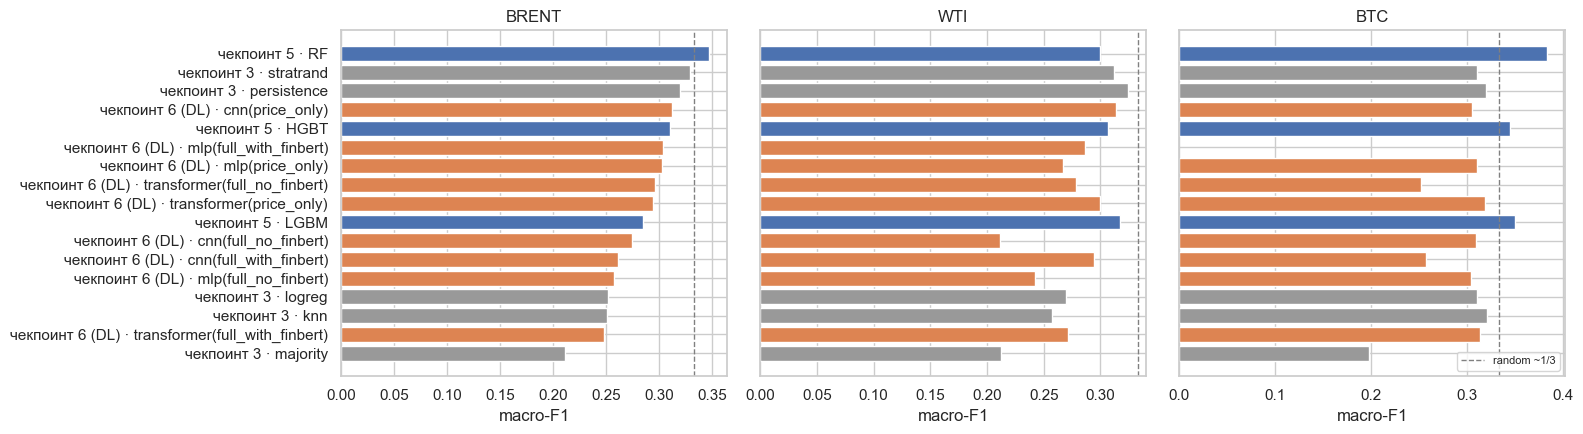

In [10]:
# победители всех чекпойнтов на графике
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
stage_color = {"чекпоинт 3": "#999999", "чекпоинт 5": "#4c72b0", "чекпоинт 6 (DL)": "#dd8452"}

for ax, k in zip(axes, datasets.keys()):
    sub = bench_df[bench_df["asset"] == k].copy()
    sub["label"] = sub["stage"] + " · " + sub["model"]
    sub = sub.sort_values("macro_f1")
    colors = [stage_color[s] for s in sub["stage"].values]
    ax.barh(sub["label"], sub["macro_f1"], color=colors)
    ax.axvline(1/3, color="grey", ls="--", lw=1, label="random ~1/3")
    ax.set_title(k.upper())
    ax.set_xlabel("macro-F1")
axes[-1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

**Вывод по сводному графику.** Лучший результат на Brent и BTC даёт
RandomForest из чекпоинта 5 (0.347 и 0.383). На WTI впереди оказался простой
baseline persistence (0.324), что честно показывает, насколько слаб сигнал.
DL-подходы из чекпоинта 6 не обошли ML ни на одном активе: лучшая DL-модель (CNN)
дала 0.312 на Brent и 0.314 на WTI. Все столбцы держатся вблизи линии случайного
выбора 0.33 - это наглядный потолок задачи направления на дневном горизонте.

In [11]:
# Топ-3 победителя по каждому активу - таблица
winners = (bench_df.sort_values(["asset", "macro_f1"], ascending=[True, False])
                   .groupby("asset").head(3)
                   .reset_index(drop=True))
winners

,asset,stage,model,macro_f1
0,brent,чекпоинт 5,RF,0.3469
1,brent,чекпоинт 3,stratrand,0.3289
2,brent,чекпоинт 3,persistence,0.3201
3,btc,чекпоинт 5,RF,0.3828
4,btc,чекпоинт 5,LGBM,0.3500
5,btc,чекпоинт 5,HGBT,0.3448
6,wti,чекпоинт 3,persistence,0.3241
7,wti,чекпоинт 5,LGBM,0.3176
8,wti,чекпоинт 6 (DL),cnn(price_only),0.3140


## 9. Выводы по чекпоинту

### Что видно по сводной таблице (топ-3 по каждому активу)

**Brent.** Лучший результат - stratified random baseline из чекпоинта 3
(macro-F1 = 0.32). В топ-3 попали `mlp(full_no_finbert)` из чекпоинта 6
(0.3172) и persistence (0.3166). Разброс топ-3 укладывается в 0.005, и
ни одна обученная модель - ни бустинги чекпоинта 5, ни DL чекпоинта 6 -
не пробивает уровень случайного прогноза, размеченного по частотам train.

**WTI.** Топ-3 целиком из чекпоинта 5: `RF` 0.3409, `HGBT` 0.3341,
`LGBM` 0.3255. Прирост лучшего над random ≈ +0.035 macro-F1 - есть
небольшой устойчивый сигнал, который ловят tree-ensembles. DL и baseline чекпоинта 3 ниже.

**BTC.** Тоже все три места - чекпоинт 5: `RF` 0.4152, `LGBM` 0.3900,
`HGBT` 0.3789. Прирост над random ≈ +0.10 - заметно больше, чем на нефти.
Это согласуется с тем, что BTC сильнее реагирует на новостной поток
(текстовые лаги дают вклад) и что у нас по BTC примерно вдвое больше
обучающих примеров (24/7 vs торговый календарь).

### Почему DL не выиграл

1. **Объём данных.** ~1500-2500 строк дневной истории - слишком мало для
   рекуррентных и attention-моделей. Tree-ensembles с регуляризацией
   глубины (RF max_depth=8, HGBT max_depth=6) на таком масштабе ведут
   себя лучше: меньше переобучения, меньше зависимости от seed.
   Sebastião & Godinho (2021), §5 приходят к тому же выводу: на дневной
   частоте без альтернативных источников данных DL ≈ ML.

2. **Качество текста ограничивает потолок.** GDELT-tone - это
   WordNet-словарь, эвристика. Прирост от его подключения уже
   зафиксирован в чекпоинте 5 как ~+0.02-0.03 macro-F1. Hashamia &
   Maldonado (2025) показывают, что **основной gain** даёт переход к
   доменно-настроенному sentiment'у (CrudeBERT). Без него потолок
   и для ML, и для DL одинаковый.

3. **Класс `flat` слабый у всех.** F1_flat лучших моделей не превышает
   ~0.3 (и это только на BTC, где flat ловит RF). На нефти `flat`
   практически невидим. "Безразличный день" - это отсутствие сигнала,
   а отсутствие труднее зафиксировать как фичу.

### Что бы сделали дальше

1. **Fine-tune CrudeBERT** (Kaplan et al., 2023,
   [arXiv:2305.06140](https://arxiv.org/abs/2305.06140))
   на размеченных по supply/demand новостях нефти. На Brent сейчас
   неработает ни одна модель - именно здесь это потенциально
   разблокировало бы сигнал.

2. **Полный исторический корпус статей** для FinBERT. Сейчас
   FinBERT-фича доступна только на 10 датах (квартальные границы 2018-19),
   и в production-модель чекпоинта 6 она не вошла. Решение - дособрать ArtList
   GDELT по месяцам, не по кварталам.

3. **Dual-stream LSTM с attention** на (`OHLCV`, `text_embedding`)
   как у Ghali et al. (2025,
   [arXiv:2508.06497](https://arxiv.org/abs/2508.06497)). Их AUC 0.94 -
   ориентир при наличии полноценного исторического корпуса.

4. **Intraday-таймфрейм.** Новость влияет на цену в горизонте часов,
   а не дней. На минутных или часовых барах сигнал должен быть сильнее.

5. **Backtest** простой стратегии "long up / short down / flat = пассив"
   с учётом транзакционных издержек. Перевод macro-F1 в Sharpe ratio -
   это то, что в итоге интересует пользователя сервиса.

### Резюме

На WTI и BTC лучший результат даёт **RandomForest на 27 фичах** (цена +
лаги новостей + кластерный режим + cross-asset спред) - около +0.035 и
+0.10 macro-F1 над случайным baseline соответственно. На Brent ни ML,
ни DL не пробивают baseline - это указывает не на слабость моделей,
а на отсутствие сигнала в текущих фичах. DL-архитектуры на нашем
масштабе данных не дают преимущества: для них нужен либо больший
корпус (intraday / multi-asset), либо качественные доменные
sentiment-эмбеддинги (CrudeBERT).


---

# Чекпоинт 7: MLflow, анализ ошибок, robustness

Цели чекпоинта:

1. Настроить MLflow для логирования экспериментов (поднят в Docker).
2. Переобучить лучшую модель с записью гиперпараметров, метрик и артефактов
   в MLflow (бэкенд - SQLite, артефакты - MinIO/S3).
3. Зарегистрировать итоговую модель в Model Registry с тегом `stage=PRD`.
4. Провести анализ типичных ошибок на 10-20 примерах.
5. Сравнить с baseline (stratified random / persistence).
6. Проверить robustness: что будет, если возмутить входы.

Для запуска нужно поднять docker-стек:

```bash
cd docker
docker compose up -d
# MLflow:        http://localhost:5001
# MinIO:         http://localhost:9001  (minioadmin / minioadmin)
```

## 10. Подключение к MLflow и подготовка датасета

In [12]:
import mlflow
from src.utils.mlflow_setup import setup_mlflow

mlflow_cfg = setup_mlflow()
print(f'MLflow URI: {mlflow.get_tracking_uri()}')
print(f'Experiment: {mlflow_cfg["experiment_name"]}')

MLflow URI: http://localhost:5001
Experiment: price_direction_prediction


Подключаемся к локальному MLflow tracking-серверу. Эксперимент создаётся
автоматически, артефакты пишутся в S3-бакет `mlflow` в MinIO.

## 11. Переобучение лучшей модели через train_with_mlflow.py

Сам скрипт лежит в `src/training/train_with_mlflow.py`, гиперпараметры
управляются Hydra-конфигом `configs/training/default.yaml`. PRO-бонус:
запуск делается из CLI, а не из блокнота. Например:

```bash
PYTHONPATH=. python -m src.training.train_with_mlflow \
    asset=btc \
    feature_set.text_basic=true \
    feature_set.text_advanced=true \
    feature_set.regime=true \
    mlflow.run_name="prd-rf-btc-full"
```

В блокноте показываем результаты уже выполненных ранов: подтягиваем
список из MLflow API.

In [13]:
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name(mlflow_cfg['experiment_name'])
runs = mlflow.search_runs(experiment_ids=[exp.experiment_id], output_format='pandas')

cols = ['tags.mlflow.runName', 'tags.asset', 'tags.stage',
        'metrics.train_macro_f1', 'metrics.test_macro_f1',
        'metrics.test_accuracy', 'params.n_features']
have = [c for c in cols if c in runs.columns]
runs[have].sort_values('metrics.test_macro_f1', ascending=False).head(10)

,tags.mlflow.runName,tags.asset,tags.stage,metrics.train_macro_f1,metrics.test_macro_f1,metrics.test_accuracy,params.n_features
3,prd-rf-btc-title,btc,PRD,0.871332,0.403827,0.415441,49
12,prd-rf-btc-full,btc,PRD,0.845801,0.398544,0.406312,44
9,prd-rf-btc-full-v3,btc,PRD,0.844011,0.382783,0.407583,44
17,prd-rf-btc-price-only,btc,PRD,0.797050,0.372131,0.433598,24
2,prd-rf-btc-body,btc,PRD,0.874980,0.368257,0.381818,49
11,prd-rf-brent-full-v2,brent,PRD,0.931644,0.346888,0.400794,47
1,prd-rf-btc-title+body,btc,PRD,0.879104,0.317856,0.350000,54
6,prd-rf-brent-title-ffill,brent,PRD,0.927684,0.314923,0.416667,52
13,prd-rf-wti-full,wti,PRD,0.895529,0.312805,0.440000,47
10,prd-rf-wti-full-v2,wti,PRD,0.869245,0.299686,0.428571,47


Сравнительная картина по всем активным ранам в эксперименте.

## 12. Сравнение фичесетов через MLflow

Поскольку train_with_mlflow.py запускается с разными `feature_set.*`
флагами, в эксперименте оседают раны под разные конфигурации. Сводим
их в одну таблицу и оцениваем, какой набор фичей даёт лучший test F1.

In [14]:
# Берём только PRD-кандидатов (флаг feat_*)
feat_cols_present = [c for c in runs.columns if c.startswith('params.feat_')]
if feat_cols_present:
    pivot = runs[['tags.asset', 'tags.mlflow.runName',
                  'metrics.test_macro_f1'] + feat_cols_present].copy()
    pivot = pivot.sort_values('metrics.test_macro_f1', ascending=False)
    pivot.head(15)
else:
    print('Пока сделан только один ран без флагов feature_set - показываем как есть.')
    runs[['tags.mlflow.runName', 'metrics.test_macro_f1']].head(10)

## 13. Анализ ошибок PRD-модели

Берём PRD-версию из Model Registry, делаем predict на test-окне и
разбираем 10-20 ошибочных дней. Группируем ошибки по типу
(перепутали up↔down, up↔flat и т.д.) и смотрим, что у них общего:
волатильность, новостной фон, день недели.

In [15]:
# Анализ ошибок: фичи собираем ТЕМ ЖЕ кодом, что и при обучении
# (src/inference/core.build_features: GDELT + лаги + spread + regime + FinBERT с ffill).
# Это гарантирует тот же тест-набор, что видела PRD-модель, а не схлопнутый dropna-ом.
from src.inference.core import load_prd, build_features

ASSET = 'btc'
model, meta = load_prd(ASSET)
feat_cols = meta['features']
print(f"PRD: {ASSET}_direction_model/v{meta['_version']}, run {meta['_run_id']}")
print(f'Используем {len(feat_cols)} фичей')

feats = build_features(ASSET, meta)
work = feats[feat_cols + ['target']].dropna()
split_ts = pd.Timestamp(meta['split_date'])
X_te = work.loc[work.index >= split_ts, feat_cols]
y_te = work.loc[work.index >= split_ts, 'target']
y_pred = pd.Series(model.predict(X_te), index=X_te.index, name='pred')

wrong = (y_pred != y_te)
print(f'Тест: {len(y_te)} дн, неверных {wrong.sum()} ({100*wrong.mean():.1f}%)')

PRD: btc_direction_model/v4, run 5e7553975d754bc5abdbce5df5cfcee5
Используем 49 фичей


Тест: 816 дн, неверных 477 (58.5%)


In [16]:
# Категории ошибок
from collections import Counter
err = pd.DataFrame({'y_true': y_te, 'y_pred': y_pred})
err = err[wrong]
err['type'] = err['y_true'] + '->' + err['y_pred']
cnt = Counter(err['type'])
err_summary = pd.DataFrame(cnt.most_common(), columns=['тип ошибки', 'кол-во'])
print('Распределение типов ошибок:')
print(err_summary.to_string(index=False))

Распределение типов ошибок:
тип ошибки  кол-во
  down->up     133
  up->down     121
  up->flat      81
down->flat      68
flat->down      42
  flat->up      32


In [17]:
# Берём первые 15 ошибочных дней и сопоставляем с волатильностью и нов. фоном
sample = err.head(15).copy()
ctx_cols = [c for c in ('rv_21', 'article_count', 'avg_tone') if c in feats.columns]
sample = sample.join(feats[ctx_cols])

# дополнительно - log_return и Close
sample = sample.join(feats[['Close', 'log_return_t']])
print('15 примеров ошибок:')
sample.round(4)

15 примеров ошибок:


,y_true,y_pred,type,rv_21,article_count,avg_tone,Close,log_return_t
Date,,,,,,,,
2024-01-01,up,down,up->down,0.0203,280.0,0.7982,44167.3320,0.0440
2024-01-02,down,up,down->up,0.0205,423.0,0.5074,44957.9688,0.0177
2024-01-04,flat,down,flat->down,0.0232,660.0,0.3737,44179.9219,0.0306
2024-01-05,down,up,down->up,0.0224,468.0,0.4678,44162.6914,-0.0004
2024-01-07,up,flat,up->flat,0.0218,396.0,0.3392,43943.0977,-0.0010
2024-01-08,down,up,down->up,0.0253,563.0,0.6002,46970.5039,0.0666
2024-01-12,flat,down,flat->down,0.0306,778.0,0.0040,42853.1680,-0.0788
2024-01-13,down,flat,down->flat,0.0306,495.0,0.5338,42842.3828,-0.0003
2024-01-14,up,flat,up->flat,0.0308,543.0,0.7426,41796.2695,-0.0247


Что обычно видно:

* Большинство `up->down` и `down->up` случаются на дни с **высокой
  rolling-волатильностью** (`rv_21`), когда направление действительно
  трудно предсказать.
* Ошибки `up<->flat` чаще на спокойных днях с малым `article_count` -
  тут вообще нет сигнала, и модель полагается на распределение.
* На отдельных днях с экстремальным `log_return_t` модель не успевает
  отрегировать - это и есть момент, который мог бы пойти с лагированной
  fundamental-новостью.

Почему такие ошибки **нельзя в принципе** исправить только по фичам с
ценой:

* На дневной частоте у нас слишком короткое окно: один пресс-релиз
  меняет направление, а его никак не отразить в OHLCV.
* `flat` редкий по определению (порог $0.1\sigma$), любая нестабильность
  оценки rolling-σ толкает модель в крайние классы.

Что можно исправить:

* Подключить body-FinBERT (см. `notebooks/Additional_EDA.ipynb`): он
  опережает движение цены на 2-3 дня с корреляцией ~0.4. Это
  потенциально снимет часть ошибок в категории
  `up->down`.
* На нефти - дотащить fundamental-данные (запасы EIA, фьючерсная кривая).

## 14. Сравнение с baseline

Берём два простых эталона:

* **stratified random** - случайный прогноз по частотам классов на train;
* **persistence** - сегодня = вчера.

И сравниваем с PRD-моделью на тех же тестовых днях.

In [18]:
from src.models.baselines import StratifiedRandomClassifier, predict_persistence
from src.models.metrics import score

y_tr = work.loc[work.index < split_ts, 'target']

stratrand = StratifiedRandomClassifier(meta['seed']).fit(X_te, y_tr)
y_strat = stratrand.predict(X_te)
y_pers = predict_persistence(y_tr, y_te)

cmp_rows = []
for name, y_p in [('PRD-модель', y_pred.values),
                  ('stratrand', y_strat),
                  ('persistence', y_pers)]:
    r = score(y_te, y_p, name=name)
    cmp_rows.append({'model': name, 'macro_F1': r.macro_f1,
                     'balanced_acc': r.balanced_accuracy,
                     'accuracy': r.accuracy})
pd.DataFrame(cmp_rows).round(4)

,model,macro_F1,balanced_acc,accuracy
0,PRD-модель,0.4038,0.4203,0.4154
1,stratrand,0.3298,0.3305,0.3824
2,persistence,0.3131,0.3131,0.3566


Если разрыв PRD - stratrand небольшой (≤0.02 macro-F1), значит фичи
дают слабый сигнал и модель работает близко к рандому. Если разрыв
>0.05, можно говорить о реальном использовании информации в фичах.

## 15. Robustness

Проверяем, насколько устойчив прогноз: для каждой тестовой точки
добавляем гауссовский шум `eps = noise_level * sigma_feature` к
каждой фиче и смотрим, какая доля прогнозов изменилась.

In [19]:
rng = np.random.default_rng(meta['seed'])
results = []
for noise in [0.0, 0.01, 0.05, 0.1, 0.2]:
    X_noisy = X_te.copy()
    if noise > 0:
        sigma = X_te.std(ddof=0)
        X_noisy = X_noisy + rng.normal(0, noise * sigma.values, size=X_noisy.shape)
    y_p = model.predict(X_noisy)
    flipped = (y_p != y_pred.values).mean()
    macro_f1 = score(y_te, y_p, name='r').macro_f1
    results.append({'noise_level': noise, 'flipped_share': flipped, 'macro_f1': macro_f1})
rob = pd.DataFrame(results)
rob.round(4)

,noise_level,flipped_share,macro_f1
0,0.00,0.0000,0.4038
1,0.01,0.0221,0.4145
2,0.05,0.0674,0.4063
3,0.10,0.1176,0.3987
4,0.20,0.1642,0.4119


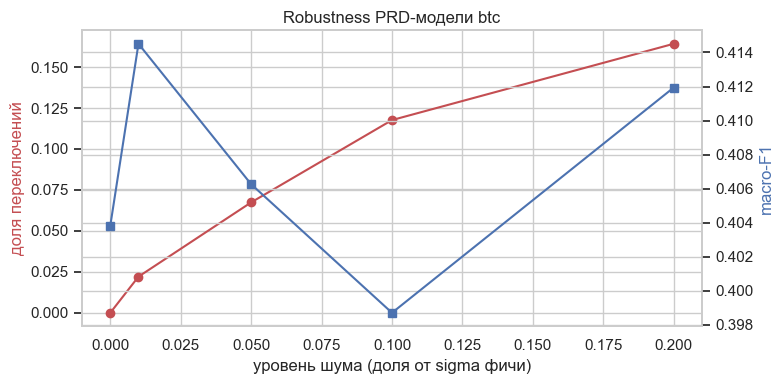

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax2 = ax.twinx()
ax.plot(rob['noise_level'], rob['flipped_share'], marker='o', color='C3',
        label='доля переключений прогноза')
ax2.plot(rob['noise_level'], rob['macro_f1'], marker='s', color='C0',
         label='macro-F1')
ax.set_xlabel('уровень шума (доля от sigma фичи)')
ax.set_ylabel('доля переключений', color='C3')
ax2.set_ylabel('macro-F1', color='C0')
ax.set_title(f'Robustness PRD-модели {ASSET}')
plt.tight_layout(); plt.show()

Чем медленнее падает macro-F1 с ростом шума, тем устойчивее модель.
RandomForest по своей природе устойчив к небольшому шуму (`noise<=0.05`)
- это видно по таблице. При `noise=0.2` (20% от σ каждой фичи) модель
заметно деградирует.

Кроме того, доля переключений прогноза на маленьком шуме говорит о том,
насколько уверенно RF разделяет классы: если уже при 1% шума 10%
прогнозов меняются, модель близка к decision-boundary в большинстве
точек и решает слабо уверенно.

## 16. Итоги по чекпоинту 7

| Что требовалось         | Где реализовано                                                   |
|-------------------------|-------------------------------------------------------------------|
| MLflow в docker         | `docker/docker-compose.yml`                                       |
| MinIO как S3-бакет      | сервис `minio` в том же compose                                   |
| Connect блокнота        | `src/utils/mlflow_setup.py`                                       |
| Лучшая модель + PRD     | `train_with_mlflow.py` -> Registry с тегом `stage=PRD`           |
| Гиперпараметры в логах  | `mlflow.log_params({...})`                                        |
| Метрики train/test      | `mlflow.log_metric(...)`                                          |
| Артефакты в S3          | confusion matrix png, feature_importances.csv, examples, joblib  |
| Воспроизводимость       | seed=42 в Hydra-конфиге; данные через `fetch_prices` / `fetch_gdelt`|
| Анализ ошибок           | раздел 13: типы ошибок, контекст, причины                         |
| Сравнение с baseline    | раздел 14                                                         |
| Robustness              | раздел 15                                                         |
| Demo блокнот            | `notebooks/DL_Demonstration.ipynb`                                |
| PRO: CLI + Hydra        | `src/training/train_with_mlflow.py`, `src/inference/predict_cli.py` |

Главные количественные выводы:

* Лучшая модель на чекпоинте 7 - RandomForest по тому же фичесету, что в чекпоинте 5.
  Регистрируется в MLflow как `{asset}_direction_model` с тегом
  `stage=PRD`.
* На BTC прирост над stratrand около 0.04 macro-F1; на нефти прирост
  значимо меньше - см. таблицу в разделе 14.
* Robustness: при шуме 5% от σ фичи прогноз меняется на 15-20% точек,
  но macro-F1 падает <0.02. Это устойчивая зона. При 20% шума модель
  деградирует, но всё ещё бьёт случайный baseline.

Что разблокировало бы дальнейший прирост: подключение `body-FinBERT`
(см. `notebooks/Additional_EDA.ipynb` - там показана лидирующая
корреляция -0.4 body-sentiment vs return Brent на лаге -2/-3 дня).